# Exercises lecture 1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/spinjo/ml-lecture-ippp-2026/blob/main/exercises_lecture1.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch

In [3]:
# colab has GPUs (=cuda)
# Additional connection options -> Change runtime type -> T4 GPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"device: {device}")

device: cuda


### 1)  `torch` = `numpy` with some add-ons for machine learning

If you are familiar with manipulating arrays in `numpy`, working with `torch` will feel quite familiar. Most commands port over, there are just a few subtle differences.

In [4]:
x_list = [1., 2., 3.]
x_np = np.array(x_list)
x_torch = torch.tensor(x_list)

In [5]:
print(np.mean(x_np, axis=0), torch.mean(x_torch, dim=0), x_torch.mean(dim=0))

2.0 tensor(2.) tensor(2.)


In [6]:
x_torch.numpy()

array([1., 2., 3.], dtype=float32)

In [7]:
x_cuda = x_torch.to(device)
x_cpu = x_cuda.cpu()
print(x_torch.device, x_cuda.device, x_cpu.device)

cpu cuda:0 cpu


In [8]:
np.linspace(0, 5, 10)
torch.linspace(0, 5, 10)

tensor([0.0000, 0.5556, 1.1111, 1.6667, 2.2222, 2.7778, 3.3333, 3.8889, 4.4444,
        5.0000])

In [9]:
np.concatenate([i*np.ones(10) for i in range(5)], axis=0)
torch.cat([i*torch.ones(10) for i in range(5)], dim=0)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.])

### 2) `torch.autograd`

`autograd`, i.e. the option to calculate gradients of functions on-the-fly, is the main feature that sets `torch` apart from `numpy`. In practice, this 

In [10]:
# tensor -> nn.Parameter
x_tensor = torch.tensor([5.])
x_param = torch.nn.Parameter(x_tensor)
print(x_tensor.requires_grad, x_param.requires_grad)
print(x_param.data, x_param.grad)

False True
tensor([5.]) None


In [11]:
# gradient calculation with autograd
loss = x_param**2
loss.backward()
print(x_param.data, x_param.grad)

tensor([5.]) tensor([10.])


In [12]:
# 'detached' tensors are not included in gradient computation
x_detached = x_param.detach()
print(x_param.requires_grad, x_detached.requires_grad)

True False


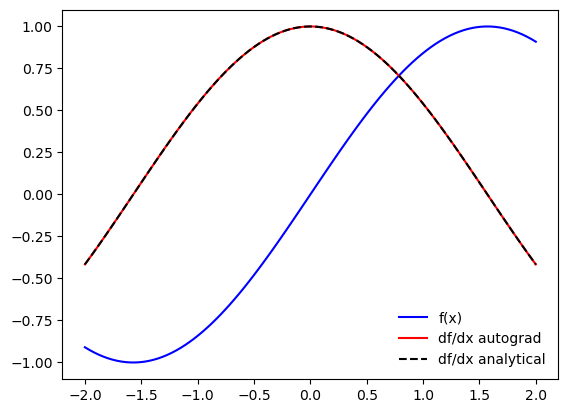

In [13]:
# derivative of sin(x)
x = torch.linspace(-2, 2, 100)
def f(x):
    return torch.sin(x)
def df_dx(x):
    return torch.cos(x)
x.requires_grad_()
df_dx_autograd = torch.autograd.grad(f(x), x, grad_outputs=torch.ones_like(x))[0]
x = x.detach()

plt.plot(x, f(x), "b-", label="f(x)")
plt.plot(x, df_dx_autograd.detach(), "r-", label="df/dx autograd")
plt.plot(x, df_dx(x), "k--", label="df/dx analytical")
plt.legend(frameon=False)
plt.show()

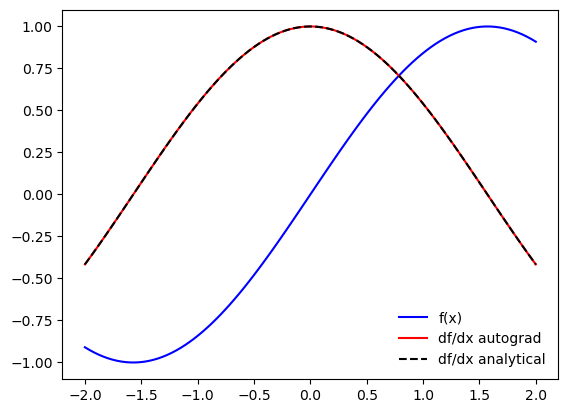

In [14]:
# custom autograd sin(x) function
class CustomSin(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        # Save x for use in backward
        ctx.save_for_backward(x)

        # Forward computation
        return torch.sin(x)

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensor
        (x,) = ctx.saved_tensors

        # d/dx sin(x) = cos(x)
        grad_x = grad_output * torch.cos(x)

        return grad_x
    
# quick test using the code from above
x = torch.linspace(-2, 2, 100)
def f(x):
    return CustomSin.apply(x)  # replace torch.sin(x) here
def df_dx(x):
    return torch.cos(x)
x.requires_grad_()
df_dx_autograd = torch.autograd.grad(f(x), x, grad_outputs=torch.ones_like(x))[0]
x = x.detach()

plt.plot(x, f(x), "b-", label="f(x)")
plt.plot(x, df_dx_autograd.detach(), "r-", label="df/dx autograd")
plt.plot(x, df_dx(x), "k--", label="df/dx analytical")
plt.legend(frameon=False)
plt.show()

### 3) Minimal workflow - neural network classifier

In [15]:
# generate data
def get_data(N, mean=1, std=1):
    x_plus = torch.randn(N, 1) * std + mean
    x_minus = torch.randn(N, 1) * std - mean
    x = torch.cat([x_plus, x_minus], dim=0)
    labels = torch.cat([torch.ones_like(x_plus), torch.zeros_like(x_minus)], dim=0)
    return x, labels
x, labels = get_data(1000)

In [16]:
# goal: learn perfect classifier (likelihood ratio)
def prob_gauss(x, mean=1, std=1):
    return 1 / (2 * torch.pi * std**2)**0.5 * torch.exp(-(x-mean)**2 / (2*std**2))

x_lin = torch.linspace(-4, 4, 1000)
prob_plus = prob_gauss(x_lin, mean=1)
prob_minus = prob_gauss(x_lin, mean=-1)
likelihood_ratio = prob_plus / (prob_plus + prob_minus)

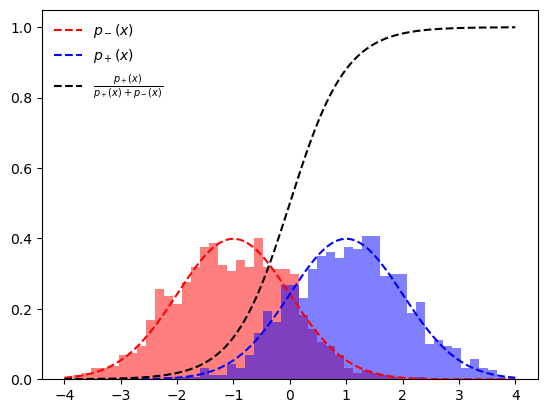

In [17]:
kwargs = dict(bins=50, range=[-4,4], alpha=0.5, density=True)
plt.hist(x[labels==0], **kwargs, color="r")
plt.hist(x[labels==1], **kwargs, color="b")

plt.plot(x_lin, prob_minus, "r--", label=r"$p_-(x)$")
plt.plot(x_lin, prob_plus, "b--", label=r"$p_+(x)$")
plt.plot(x_lin, likelihood_ratio, "k--", label=r"$\frac{p_+(x)}{p_+(x)+p_-(x)}$")
plt.legend(frameon=False)
plt.show()

In [18]:
# train, test, val dataset
x_train, labels_train = get_data(1000)
x_val, labels_val = get_data(100)
x_test, labels_test = get_data(1000)

from torch.utils.data import TensorDataset
data_train = TensorDataset(x_train, labels_train)
data_val = TensorDataset(x_val, labels_val)
data_test = TensorDataset(x_test, labels_test)

print(f"Training events: {len(data_train)}")

Training events: 2000


In [19]:
# data loader
from torch.utils.data import DataLoader

batch_size = 128
loader_train = DataLoader(data_train, batch_size=batch_size, drop_last=True, shuffle=True)
loader_val = DataLoader(data_val, batch_size=batch_size)
loader_test = DataLoader(data_test, batch_size=batch_size)

x, label = next(iter(loader_train))
print(x.shape, label.shape)

print(f"Number of batches: {len(loader_train)}")

torch.Size([128, 1]) torch.Size([128, 1])
Number of batches: 15


In [20]:
# neural network - MLP
from torch import nn
class MLP(nn.Module):
    def __init__(self, channels_in, channels_out, channels_hidden=32, num_layers=3, dropout_prob=None):
        super().__init__()
        layers = []
        layers.append(nn.Linear(channels_in, channels_hidden))
        for _ in range(num_layers):
            layers.append(nn.Linear(channels_hidden, channels_hidden))
            layers.append(nn.GELU())
            if dropout_prob is not None:
                layers.append(nn.Dropout(dropout_prob))
        layers.append(nn.GELU())
        layers.append(nn.Linear(channels_hidden, channels_out))
        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, inputs):
        return self.layers(inputs)

mlp = MLP(channels_in=1, channels_out=1)
out = mlp(x)
print(out.shape)

num_params = sum(p.numel() for p in mlp.parameters())
print(f"Parameter count: {num_params}")

mlp = mlp.to(device)

torch.Size([128, 1])
Parameter count: 3265


In [21]:
# training
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
epochs = 10
steps_per_epoch = len(loader_train)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs*steps_per_epoch)
loss_fn = torch.nn.BCEWithLogitsLoss()

losses = []
lrs = []
losses_val = []
for epoch in range(epochs):
    # training
    for step, (x, label) in enumerate(loader_train):
        x, label = x.to(device), label.to(device)
        logit = mlp(x)
        loss = loss_fn(logit, label)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        scheduler.step()
        lrs.append(scheduler.get_last_lr())
        
        print(f"Epoch {epoch:>3}/{epochs}, step {step:>4}: loss={loss.item():.4f}")
        
    # validation
    buffer = []
    for (x, label) in loader_val:
        x, label = x.to(device), label.to(device)
        logit = mlp(x)
        loss = loss_fn(logit, label)
        buffer.append(loss)
    val_loss = torch.stack(buffer).mean()
    losses_val.append(val_loss.item())

Epoch   0/10, step    0: loss=0.6804
Epoch   0/10, step    1: loss=0.7050
Epoch   0/10, step    2: loss=0.7017
Epoch   0/10, step    3: loss=0.6926
Epoch   0/10, step    4: loss=0.6939
Epoch   0/10, step    5: loss=0.6944
Epoch   0/10, step    6: loss=0.6796
Epoch   0/10, step    7: loss=0.6819
Epoch   0/10, step    8: loss=0.6807
Epoch   0/10, step    9: loss=0.6898
Epoch   0/10, step   10: loss=0.6791
Epoch   0/10, step   11: loss=0.6874
Epoch   0/10, step   12: loss=0.6764
Epoch   0/10, step   13: loss=0.6740
Epoch   0/10, step   14: loss=0.6704
Epoch   1/10, step    0: loss=0.6673
Epoch   1/10, step    1: loss=0.6628
Epoch   1/10, step    2: loss=0.6609
Epoch   1/10, step    3: loss=0.6574
Epoch   1/10, step    4: loss=0.6416
Epoch   1/10, step    5: loss=0.6420
Epoch   1/10, step    6: loss=0.6532
Epoch   1/10, step    7: loss=0.6237
Epoch   1/10, step    8: loss=0.6209
Epoch   1/10, step    9: loss=0.6104
Epoch   1/10, step   10: loss=0.6128
Epoch   1/10, step   11: loss=0.5889
E

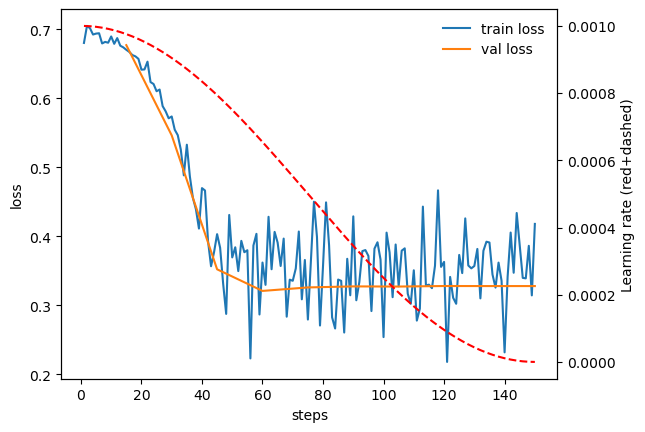

In [22]:
# visualize loss and lr curves
steps = torch.arange(steps_per_epoch * epochs) + 1
epochs = torch.arange(epochs) + 1
fig, ax = plt.subplots()
ax.plot(steps, losses, label="train loss")
ax.plot(epochs * steps_per_epoch, losses_val, label="val loss")
ax.set_xlabel("steps")
ax.set_ylabel("loss")

axr = ax.twinx()
axr.plot(steps, lrs, "r--")
axr.set_ylabel("Learning rate (red+dashed)")
ax.legend(frameon=False)
plt.show()

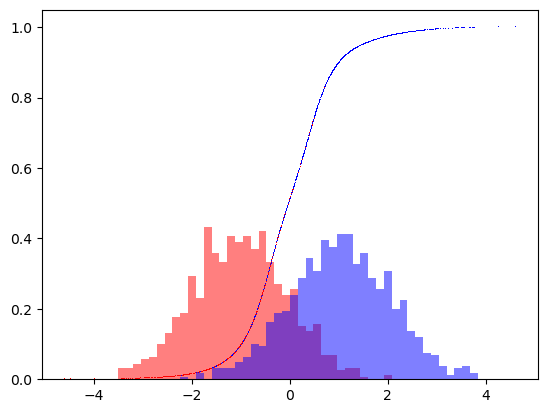

In [23]:
# evaluation: logits
with torch.no_grad():
    probs = []
    labels = []
    xs = []
    for (x, label) in loader_test:
        x, label = x.to(device), label.to(device)
        logit = mlp(x)
        prob = torch.sigmoid(logit)
        xs.append(x)
        probs.append(prob)
        labels.append(label)
    xs = torch.cat(xs).cpu()
    probs = torch.cat(probs).cpu()
    labels = torch.cat(labels).cpu()
    
plt.hist(xs[labels==0], **kwargs, color="r")
plt.hist(xs[labels==1], **kwargs, color="b")
plt.plot(xs[labels==0], probs[labels==0], "r,")
plt.plot(xs[labels==1], probs[labels==1], "b,")
plt.show()

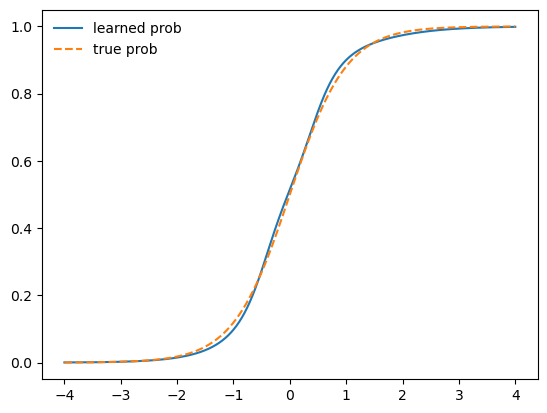

In [24]:
# evaluation: likelihood ratio
with torch.no_grad():
    x = torch.linspace(-4, 4, 1000).to(device)
    logit = mlp(x.unsqueeze(-1)).cpu()
    prob_learned = torch.sigmoid(logit)
    x = x.cpu()

prob_true = prob_gauss(x, mean=1) / (prob_gauss(x, mean=-1) + prob_gauss(x, mean=1))

plt.plot(x, prob_learned, label="learned prob")
plt.plot(x, prob_true, label="true prob", linestyle="--")
plt.legend(frameon=False)
plt.show()

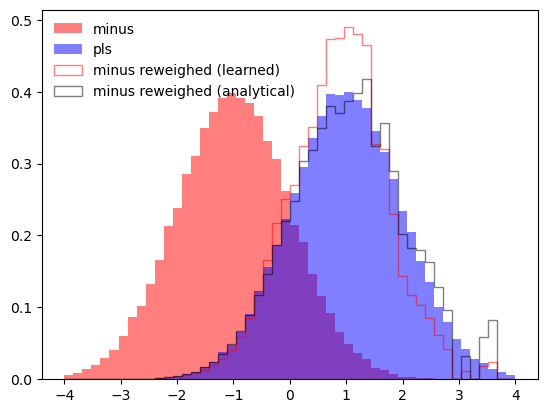

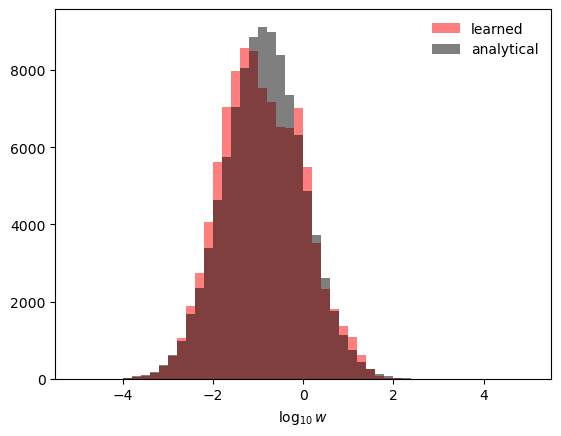

In [25]:
# bonus: reweighting
xs, labels = get_data(100000)  # more data

# evaluation copied from above
with torch.no_grad():
    logits = mlp(xs.to(device)).cpu()
probs = torch.sigmoid(logits)
    
plt.hist(xs[labels==0], **kwargs, color="r", label="minus")
plt.hist(xs[labels==1], **kwargs, color="b", label="pls")

# reweighting 'minus' events to 'plus' events
x_minus = xs[labels==0]
probs_minus = probs[labels==0]
weights_learned = torch.exp(logits[labels==0])
weights_analytical = prob_gauss(x_minus, mean=1) / prob_gauss(x_minus, mean=-1)

plt.hist(x_minus, weights=weights_learned, **kwargs, histtype="step", color="r", lw=1, label="minus reweighed (learned)")
plt.hist(x_minus, weights=weights_analytical, **kwargs, histtype="step", color="k", lw=1, label="minus reweighed (analytical)")
plt.legend(frameon=False, loc=2)
plt.show()

plt.hist(weights_learned.log10(), range=(-5,5), bins=50, label="learned", alpha=0.5, color="r")
plt.hist(weights_analytical.log10(), range=(-5,5), bins=50, label="analytical", alpha=0.5, color="k")
plt.xlabel(r"$\log_{10} w$")
plt.legend(frameon=False)
plt.show()